In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
# LOAD THE DATA
load_dir = '../data/processed/'


train_df = pd.read_csv(os.path.join(load_dir, 'train_engineered.csv'))
test_df = pd.read_csv(os.path.join(load_dir, 'test_engineered.csv'))

print("Data loaded successfully!")

Data loaded successfully!


In [3]:
#  SPLIT INTO X AND y 

# These are the columns the AI is NOT allowed to see during training
cols_to_hide = ['unit_nr', 'time_cycles', 'RUL']


# Training set
X_train = train_df.drop(columns=cols_to_hide) # X gets everything EXCEPT the hidden columns
y_train = train_df['RUL']                     # y gets ONLY the target answer


# Testing set
X_test = test_df.drop(columns=cols_to_hide)
y_test = test_df['RUL']

In [4]:
X_train.head()

,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,...,s_14_mean,s_14_std,s_15_mean,s_15_std,s_17_mean,s_17_std,s_20_mean,s_20_std,s_21_mean,s_21_std
0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,...,8134.194,2.651326,8.41334,0.025953,391.8,1.095445,38.958,0.073621,23.39302,0.033498
1,642.10,1584.47,1398.37,554.67,2388.02,9049.68,47.16,521.68,2388.03,8132.85,...,8133.040,0.958697,8.41160,0.025727,391.6,1.140175,38.942,0.051186,23.38260,0.031436
2,642.48,1592.32,1397.77,554.34,2388.02,9059.13,47.36,522.32,2388.03,8132.32,...,8133.206,0.643141,8.40472,0.023476,391.6,1.140175,38.962,0.086718,23.37336,0.021634
3,642.56,1582.96,1400.97,553.85,2388.00,9040.80,47.24,522.47,2388.03,8131.07,...,8132.774,1.149274,8.40268,0.022477,391.8,0.836660,38.966,0.086487,23.36664,0.034405
4,642.12,1590.98,1394.80,553.69,2388.05,9046.46,47.29,521.79,2388.05,8125.69,...,8131.146,3.205438,8.40360,0.020740,391.8,0.836660,39.000,0.077136,23.37318,0.038939


In [5]:
y_train.head()

0    187
1    186
2    185
3    184
4    183
Name: RUL, dtype: int64

In [6]:
X_test.head()

,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,...,s_14_mean,s_14_std,s_15_mean,s_15_std,s_17_mean,s_17_std,s_20_mean,s_20_std,s_21_mean,s_21_std
0,642.51,1587.19,1401.92,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,...,8131.542,5.222300,8.40488,0.024080,391.8,1.303840,38.990,0.080623,23.39368,0.020672
1,642.11,1579.12,1395.13,554.22,2388.00,9050.96,47.26,521.92,2388.08,8127.46,...,8131.924,4.720136,8.40860,0.025534,391.8,1.303840,39.000,0.061237,23.38832,0.029007
2,642.11,1583.34,1404.84,553.89,2388.05,9051.39,47.31,522.01,2388.06,8134.97,...,8130.994,2.951437,8.41082,0.022794,391.4,1.140175,38.966,0.088487,23.38904,0.029153
3,642.54,1580.89,1400.89,553.59,2388.05,9052.86,47.21,522.09,2388.06,8125.93,...,8130.160,3.748700,8.40626,0.015626,391.4,1.140175,38.960,0.079373,23.37020,0.036422
4,641.88,1593.29,1412.28,554.49,2388.06,9048.55,47.37,522.03,2388.05,8134.15,...,8130.410,4.009707,8.41498,0.017520,391.4,1.140175,38.980,0.101489,23.38588,0.051895


In [7]:
y_test.head()

0    138
1    137
2    136
3    135
4    134
Name: RUL, dtype: int64

___________________________________________________________________________

### The Baseline ( Dumb Guess )

* This code creates a simple baseline model that always predicts the average RUL, then calculates error metrics to set the minimum performance your ML model must beat.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Find the "Dumb Guess" (The average RUL in our training data)
average_rul = y_train.mean()
print(f"Our Dumb Guess: Always predict {average_rul:.2f} cycles left.\n")

# 2. Make this dumb guess for every single row in our test set
# This creates a list the exact same length as y_test, filled only with our average_rul
dumb_predictions = [average_rul] * len(y_test)

# 3. Grade the dumb guess against the actual Answer Key (y_test)
baseline_mae = mean_absolute_error(y_test, dumb_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, dumb_predictions)) # We use np.sqrt to get the Root

print(f"--- BASELINE SCORES TO BEAT ---")
print(f"Baseline MAE: {baseline_mae:.2f} cycles")
print(f"Baseline RMSE: {baseline_rmse:.2f} cycles")

Our Dumb Guess: Always predict 105.91 cycles left.

--- BASELINE SCORES TO BEAT ---
Baseline MAE: 53.62 cycles
Baseline RMSE: 67.17 cycles


### Model/ Algorithm Selection :-

* Going for the Trees

* XGBoost vs Random Forest

In [9]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Initialize the models (Using pure default settings for the "First Pass")
# random_state=42 just ensures we get the exact same results every time we run it
rf_model = RandomForestRegressor(random_state=42)
xgb_model = XGBRegressor(random_state=42)

# 2. Training models :
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

# 3. Making predictions on the unseen test values (X_test)
rf_predictions = rf_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

# 4. Grade them against the true values (y_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

# 5. The Official Scoreboard
print("\n--- THE SCOREBOARD (Mean Absolute Error) ---")
print(f"1. Dumb Baseline : 53.62 cycles")
print(f"2. Random Forest : {rf_mae:.2f} cycles")
print(f"3. XGBoost       : {xgb_mae:.2f} cycles")

print("\n--- THE SCOREBOARD (Root Mean Squared Error) ---")
print(f"1. Dumb Baseline : 67.17 cycles")
print(f"2. Random Forest : {rf_rmse:.2f} cycles")
print(f"3. XGBoost       : {xgb_rmse:.2f} cycles")

Training Random Forest...
Training XGBoost...

--- THE SCOREBOARD (Mean Absolute Error) ---
1. Dumb Baseline : 53.62 cycles
2. Random Forest : 35.04 cycles
3. XGBoost       : 37.49 cycles

--- THE SCOREBOARD (Root Mean Squared Error) ---
1. Dumb Baseline : 67.17 cycles
2. Random Forest : 46.59 cycles
3. XGBoost       : 49.53 cycles


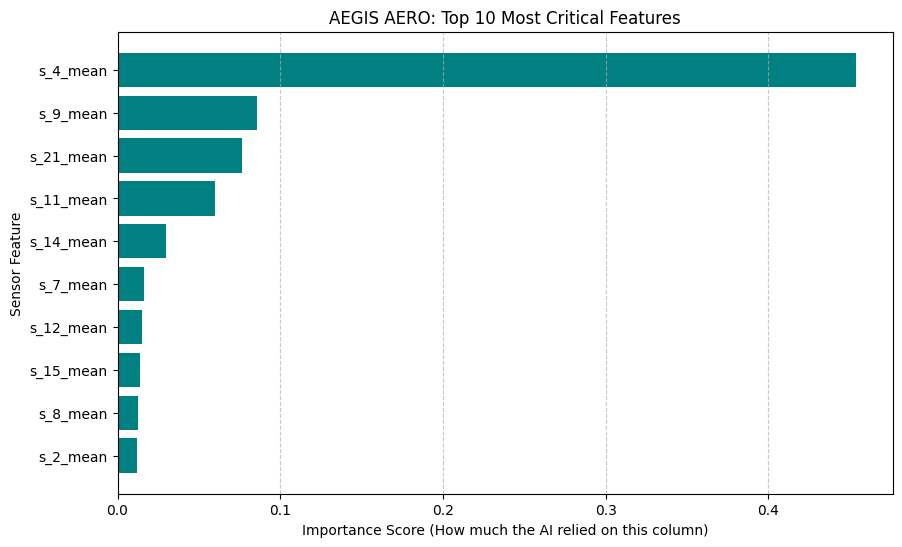

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract the "importance scores" from our current champion model
importances = rf_model.feature_importances_

# 2. Pair those scores with the actual names of our columns (sensors)
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 3. Sort them from highest to lowest and grab the Top 10
top_10_features = importance_df.sort_values(by='Importance', ascending=False).head(10)

# 4. Plot a beautiful horizontal bar chart 
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='teal')
plt.gca().invert_yaxis()  # Flips the chart so the #1 most important is at the very top
plt.title("AEGIS AERO: Top 10 Most Critical Features")
plt.xlabel("Importance Score (How much the AI relied on this column)")
plt.ylabel("Sensor Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Every single one of the Top 10 features ends in _mean. The raw, original sensors didn't even make the list! This is the ultimate proof that your Feature Engineering was a massive success. The AI completely ignored the noisy, raw, jumping sensor numbers and almost exclusively used the smoothed-out "Trends" (the rolling means) that you built from scratch. If you hadn't built that 5-cycle time machine earlier, your model would have been practically blind.

(And as a bonus, look at s_4—Burner Temperature. The heatmap told us it was important earlier, and the AI just confirmed that its trend is the #1 strongest signal of engine failure!)

In [11]:
# 1. Initialize XGBoost with custom-tuned dials
tuned_xgb = XGBRegressor(
    n_estimators=200,      # Build 200 trees instead of 100
    max_depth=4,           # Keep the trees shallow so they don't overthink
    learning_rate=0.1,     # Slow down the learning process for better precision
    random_state=42
)

# 2. Train the tuned F1 car
print("Training Tuned XGBoost...")
tuned_xgb.fit(X_train, y_train)

# 3. Take the test exam
tuned_predictions = tuned_xgb.predict(X_test)

# 4. Grade the exam
tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_predictions))

print("\n--- THE FINAL SHOWDOWN ---")
print(f"Random Forest (Default) : {rf_mae:.2f} cycles")
print(f"XGBoost (Tuned)         : {tuned_mae:.2f} cycles")

Training Tuned XGBoost...

--- THE FINAL SHOWDOWN ---
Random Forest (Default) : 35.04 cycles
XGBoost (Tuned)         : 35.34 cycles


In [12]:
import joblib
import os

# 1. Create a professional directory just for your trained models
model_dir = '../artifacts/'
os.makedirs(model_dir, exist_ok=True)

# 2. Freeze the Champion Model (Random Forest)
rf_path = os.path.join(model_dir, 'rf_champion_model.pkl')
joblib.dump(rf_model, rf_path)

# 3. Let's save the tuned XGBoost too, just so your Flask app has options!
xgb_path = os.path.join(model_dir, 'xgb_tuned_model.pkl')
joblib.dump(tuned_xgb, xgb_path)

print(f" Champion RF saved to: {rf_path}")
print(f" Backup XGBoost saved to: {xgb_path}")

 Champion RF saved to: ../artifacts/rf_champion_model.pkl
 Backup XGBoost saved to: ../artifacts/xgb_tuned_model.pkl
